In [1]:
import torch
from collections import OrderedDict  

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt
import scipy.io 
from scipy.interpolate import griddata 

import random

import skopt 
from distutils.version import LooseVersion 

from mpl_toolkits.axes_grid1 import make_axes_locatable 
import matplotlib.gridspec as gridspec 
import time 


from tqdm import tqdm 

import os
import pickle

import timeit 
import seaborn as sns 
import pandas as pd

import sys 
sys.path.insert(0, '../../..') 
from util import *

from KAN import Model

In [2]:
torch.cuda.set_device(0
                    ) 

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [3]:
# the deep neural network
class DNN(torch.nn.Module):
    #第一个方法
    def __init__(self, layers):
        super(DNN, self).__init__() #调用父类的__init__方法进行初始化
        
        # parameters
        self.depth = len(layers) - 1 #定义名为depth的属性，表示神经网络的深度，等于层数-1
        
        # set up layer order dict
        self.activation = torch.nn.Tanh #设置激活函数为tanh
         
        layer_list = list() #定义一个空列表layer_list
        for i in range(self.depth - 1):  #循环depth次
            #将每一层（全连接层）添加到layer_list中
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            #将每一层的激活函数添加到layer_list中
            layer_list.append(('activation_%d' % i, self.activation()))

        #循环结束后，将最后一层的线性变换添加到layer_list中（因为没有激活函数了）
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        #然后使用OrderedDict将layer_list中的元素转换为有序字典
        layerDict = OrderedDict(layer_list)
        
        # deploy layers，将layerDict转换为一个神经网络模型，赋值给self.layers
        self.layers = torch.nn.Sequential(layerDict)
    
    #第二个方法，定义了模型的前向传播过程
    def forward(self, x):  #接收输入x
        out = self.layers(x) #将输入x传入神经网络模型self.layers中，得到输出out
        return out #返回输出out
    
    # 新增方法，获取最后一个隐藏层的输出
    def hidden_output(self, x):
        # 遍历每一层，直到最后一个隐藏层
        for i in range(self.depth - 1):
            # 获取当前层的线性变换
            x = self.layers[i*2](x)
            # 获取当前层的激活函数
            x = self.layers[i*2 + 1](x)
        # 返回最后一个隐藏层的输出
        return x

In [4]:

class PhysicsInformedNN():
    def __init__(self, b_left, b_right, b_upper, b_lower, X_f, layers, lb, ub): 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device)

        # X_f = make_time_sequence(X_f, num_step=5, step=1e-4) 

        # b_left = make_time_sequence(b_left, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        # b_right = make_time_sequence(b_right, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        # b_upper = make_time_sequence(b_upper, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        # b_lower = make_time_sequence(b_lower, num_step=5, step=1e-4) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        
        # data
        #配位点数据
        self.x_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        # self.x_f = torch.tensor().float().to(device)
        self.t_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)

        self.x_left = torch.tensor(b_left[:, 0:1], requires_grad=True).float().to(device) #(点的数量，序列长度，1)\n",
        self.t_left = torch.tensor(b_left[:, 1:2], requires_grad=True).float().to(device)
        self.x_right = torch.tensor(b_right[:, 0:1], requires_grad=True).float().to(device) 
        self.t_right = torch.tensor(b_right[:, 1:2], requires_grad=True).float().to(device)
        self.x_upper = torch.tensor(b_upper[:, 0:1], requires_grad=True).float().to(device) 
        self.t_upper = torch.tensor(b_upper[:, 1:2], requires_grad=True).float().to(device)
        self.x_lower = torch.tensor(b_lower[:, 0:1], requires_grad=True).float().to(device)
        self.t_lower = torch.tensor(b_lower[:, 1:2], requires_grad=True).float().to(device)
        
        
        # deep neural networks
        # self.dnn = DNN(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device) 
        self.layers = layers
        self.dnn = Model(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, \
                                  noise_scale_base=0.25, device=device).to(device)

        self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10) #使用LBFGS优化器，line_search_fn='strong_wolfe'表示使用强Wolfe线搜索方法

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())

        self.optimizer_SGD = torch.optim.SGD(self.dnn.parameters(), lr=0.01, momentum=0.9)

        self.iter = 0 

        self.loss_value = [] 

    def init_weights(self, m):
        if isinstance(m, nn.Linear): 
            torch.nn.init.xavier_uniform(m.weight)
            m.bias.data.fill_(0.01)

    def net_u(self, x, t):  
        u = self.dnn(torch.cat([x, t], dim=-1))  
        return u

    def net_f(self, x, t):
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(x, t) 
        u_t = torch.autograd.grad(
            u, t,  
            grad_outputs=torch.ones_like(u), 
            retain_graph=True, 
            create_graph=True 
        )[0]

        
        f=u_t - 5 * u * (1-u) 
        return f #(点的数量，序列长度，1)
    
    def loss_func(self):
        self.optimizer_LBFGS.zero_grad() 
        
        pred_upper = self.net_u(self.x_upper, self.t_upper) 
        pred_lower = self.net_u(self.x_lower, self.t_lower) 
        pred_left = self.net_u(self.x_left, self.t_left) 
        f_pred = self.net_f(self.x_f, self.t_f) 

        loss_res = torch.mean(f_pred ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
        loss_ic = torch.mean((pred_left[:,0] - torch.exp(- (self.x_left[:,0] - torch.pi)**2 / (2*(torch.pi/4)**2))) ** 2)

        loss = loss_res + loss_bc + loss_ic
        loss.backward() 

        self.iter += 1 
        self.loss_value.append(loss) 

        return loss #返回loss

      
    
    def train(self, nIter, nIterLBFGS):
        self.dnn.train()
        for epoch in tqdm(range(nIter), desc='Adam'):
            pred_upper = self.net_u(self.x_upper, self.t_upper) 
            pred_lower = self.net_u(self.x_lower, self.t_lower) 
            pred_left = self.net_u(self.x_left, self.t_left) 
            f_pred = self.net_f(self.x_f, self.t_f) 

            #计算损失，共三项损失
            loss_res = torch.mean(f_pred ** 2)
            loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
            loss_ic = torch.mean((pred_left[:,0] - torch.exp(- (self.x_left[:,0] - torch.pi)**2 / (2*(torch.pi/4)**2))) ** 2)

            loss = loss_res + loss_bc + loss_ic

            # Backward and optimize
            self.optimizer_Adam.zero_grad() 
            loss.backward() 
            self.optimizer_Adam.step()  

            self.loss_value.append(loss)

        for i in tqdm(range(nIterLBFGS), desc='LBFGS'):
            self.dnn.train() 
            self.optimizer_LBFGS.step(self.loss_func)  

 

  


    def predict(self, X): #形状(点的数量，2)
        x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(device) #从输入中得到x和t（第一列和第二列），是张量，需要计算梯度，转换为浮点数类型，并将张量移动到指定设备上
        t = torch.tensor(X[:, 1:2], requires_grad=True).float().to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        with torch.no_grad():
            u = self.net_u(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
            # u = u[:,0:1].reshape(-1,1) #将u的形状从(点的数量，序列长度，1)变为(点的数量，1)
            u = u.detach().cpu().numpy() #将张量u和f先从计算图中分离出来，然后转换为numpy数组，最后将这个数组移动到cpu上
        return u

    
    def residual(self, X): #形状(点的数量，2)
        x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(device) #从输入中得到x和t（第一列和第二列），是张量，需要计算梯度，转换为浮点数类型，并将张量移动到指定设备上
        t = torch.tensor(X[:, 1:2], requires_grad=True).float().to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        f = self.net_f(x, t)
        f = f.detach().cpu().numpy()
        return f


    

    # def hidden_predict(self, X):#形状(点的数量，序列长度，2)
    #     x = torch.tensor(X[:, 0:1], requires_grad=True).float().to(device) #(点的数量，序列长度，1) 
    #     t = torch.tensor(X[:, 1:2], requires_grad=True).float().to(device)
    #     self.dnn.eval()
    #     with torch.no_grad():
    #         hidden_output = self.dnn.hidden_output(torch.cat([x, t], dim=-1)) #(点的数量，序列长度，2)
    #         hidden_output = hidden_output.detach().cpu().numpy()

    #     return hidden_output #(点的数量，序列长度，2)
    
    def hidden_predict(self, x,t):
        x = torch.tensor(x, requires_grad=True).float().to(device) #从输入中得到x和t（第一列和第二列），是张量，需要计算梯度，转换为浮点数类型，并将张量移动到指定设备上
        t = torch.tensor(t, requires_grad=True).float().to(device)
        self.dnn.eval()
        hidden_output = self.dnn.hidden_output(torch.cat([x, t], dim=1))
        hidden_output_x = hidden_output[:, 0]
        hidden_output_t = hidden_output[:, 1]
        hidden_output_x = hidden_output_x.detach().cpu().numpy()
        hidden_output_t = hidden_output_t.detach().cpu().numpy()
        return hidden_output_x, hidden_output_t
    

In [5]:
#定义设置随机数种子的函数，第一个参数seed表示种子；第二个参数用来设置CUDA的卷积操作是否确定性，默认为False，表示没有确定性
def set_seed(seed):
    # torch.manual_seed(seed) #设置pytorch的CPU随机数生成器的种子
    # torch.cuda.manual_seed_all(seed) #设置putorch的所有GPU随机数生成器的种子
    # np.random.seed(seed) #设置numpy的随机数生成器的种子
    # random.seed(seed) #设置python的内置随机数生成器的种子
    # torch.backends.cudnn.deterministic = deterministic #True会让CUDA的卷积操作变得确定性，即对于相同的输入，每次运行会得到相同的结果，False则相反
    """
    设置PyTorch的随机种子, 用于生成随机数. 通过设置相同的种子, 可以确保每次运行时生成的随机数序列相同
    """
    torch.manual_seed(seed)
 
    """
    设置PyTorch在所有可用的CUDA设备上的随机种子. 如果在使用GPU进行计算, 这个设置可以确保在不同的GPU上生成的随机数序列相同
    """
    torch.cuda.manual_seed_all(seed)
 
    """
    设置PyTorch在当前CUDA设备上的随机种子. 它与上一行代码的作用类似, 但只影响当前设备
    """
    torch.cuda.manual_seed(seed)
 
    """
    设置NumPy的随机种子, 用于生成随机数. 通过设置相同的种子，可以确保在使用NumPy的随机函数时生成的随机数序列相同
    """
    np.random.seed(seed)
    
    """
    设置Python内置的随机函数的种子. Python的random模块提供了许多随机函数, 包括生成随机数、打乱列表等. 通过设置相同的种子, 可以确保使用这些随机函数时生成的随机数序列相同
    """
    random.seed(seed)
    
    """
    设置Python的哈希种子 (哈希函数被广泛用于数据结构 (如字典和集合) 的实现，以及一些内部操作 (如查找和比较)). 通过设置相同的种子, 可以确保在不同的运行中生成的哈希结果相同
    """
    # os.environ["PYTHONHASHSEED"] = str(seed)
    
    """
    该设置确保每次运行代码时, cuDNN的计算结果是确定性的, 即相同的输入会产生相同的输出, 这是通过禁用一些非确定性的算法来实现的, 例如在卷积操作中使用的算法. 这样做可以保证模型的训练和推理在相同的硬件和软件环境下是可复现的, 即每次运行代码时的结果都相同. 但是, 这可能会导致一些性能上的损失, 因为禁用了一些优化的非确定性算法
    """
    torch.backends.cudnn.deterministic = True
    
    """
    该设置禁用了cuDNN的自动优化过程. 当它被设置为False时, PyTorch不会在每次运行时重新寻找最优的算法配置, 而是使用固定的算法配置. 这样做可以确保每次运行代码时的性能是一致的, 但可能会导致一些性能上的损失
    """
    torch.backends.cudnn.benchmark = False



In [6]:
import numpy as np

def calculate_chaos(model, X, num_iter, last_k=20):
    """
    计算模型在给定输入点集上的混沌度。
    参数:
    - model: 具有 hidden_predict 方法的神经网络模型，返回倒数第二层输出
    - X: 输入数据，形状为 (N_f_new, 2)，其中第一列为 x0，第二列为 t0
    - num_iter: 计算混沌情况的总迭代次数
    - last_k: 计算混沌度时考虑的最后 k 次迭代

    返回:
    - chaos_score: 每个采样点的混沌度（取最后 k 次的平均欧氏距离）
    """

    # 1. 取输入点 (x0, t0)
    x0 = X[:, 0:1]  # (N_f_new,1)
    t0 = X[:, 1:2]  # (N_f_new,1)

    # 2. 计算初始点的迭代轨迹
    xs = np.zeros((num_iter, X.shape[0], 2))  # 形状 (num_iter, N_f_new, 2)
    x, t = model.hidden_predict(x0, t0)
    x, t = x.reshape(-1,1), t.reshape(-1,1)

    for i in range(num_iter):
        x, t = model.hidden_predict(x, t)
        x, t = x.reshape(-1,1), t.reshape(-1,1)
        xs[i, :, 0] = x.flatten()  # 存储 x
        xs[i, :, 1] = t.flatten()  # 存储 t

    # 3. 给输入数据加微小扰动
    x1 = x0 + np.random.normal(0, 0.0001, size=x0.shape)
    t1 = t0 + np.random.normal(0, 0.0001, size=t0.shape)

    # 4. 计算扰动点的迭代轨迹
    xs1 = np.zeros_like(xs)  # 形状 (num_iter, N_f_new, 2)
    x, t = model.hidden_predict(x1, t1)
    x, t = x.reshape(-1,1), t.reshape(-1,1)

    for i in range(num_iter):
        x, t = model.hidden_predict(x, t)
        x, t = x.reshape(-1,1), t.reshape(-1,1)
        xs1[i, :, 0] = x.flatten()
        xs1[i, :, 1] = t.flatten()

    # 5. 计算最后 last_k 次迭代的欧氏距离
    last_xs = xs[-last_k:, :, :]  # 取最后 k 次迭代的结果
    last_xs1 = xs1[-last_k:, :, :]  # 取扰动点的结果

    # 计算最后 k 次的欧氏距离
    distances = np.linalg.norm(last_xs - last_xs1, axis=2)  # 形状 (last_k, N_f_new)

    # 6. 取最后 k 次迭代的平均混沌度
    chaos_score = np.mean(distances, axis=0)  # (N_f_new,)

    return chaos_score


In [7]:
seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321] 
# seeds = [0]

N_f = 51*51

lb = np.array([0.0, 0.0])
ub = np.array([2 * np.pi, 1.0])

_, b_left, b_right, b_upper, b_lower = get_data([0,2*np.pi], [0,1], 51, 51)
X_star, _, _, _, _ = get_data([0,2*np.pi], [0,1], 101, 101) 

error_u = [] 
error_mae = [] 
error_mse = [] 

layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 2, 1]

i = 0 

nIter = 10000 
nIterLBFGS = 500 

def hh(x):
    return np.exp( - (x-np.pi)**2 / (2 * (np.pi/4)**2))

def u_ana(x,t):
    return hh(x) * np.exp(5*t) / ( hh(x) * np.exp(5*t) + 1 - hh(x))

for seed in seeds:
    set_seed(seed) 

    N_f_1 = N_f // 20
    X_f_train = lb + (ub - lb) * lhs(2, N_f_1)
     
    model = PhysicsInformedNN(b_left, b_right, b_upper, b_lower, X_f_train, layers, lb, ub)
    start_time = time.time()          
    # 【新】创建巨大、固定的候选点池
    N_f_candidate = N_f * 2
    X_f_candidate = lb + (ub - lb) * lhs(2, N_f_candidate)
    is_point_selected_mask = np.zeros(N_f_candidate, dtype=bool) #布尔掩码，形状是(N_f_candidate,)，初始值为False，表示所有点都未被选择
    

    # --- 3. 初始训练 ---
    start_time = time.time()
    model.train(nIter // 20, 0)

    # --- 4. 主动学习循环 ---
    # 计算总轮数,这里是19
    num_active_rounds = (nIter - nIter // 20) // (nIter // 20)
    # 每轮训练中记录的检查点数量，其实就是后面的T
    num_checkpoints_per_round = 10
    # 两次检查点之间的训练迭代次数
    epochs_between_checkpoints = (nIter // 20) // num_checkpoints_per_round

    # 用于存储每一轮最终预测的全局历史
    global_final_predictions = []

    for i in range(num_active_rounds):        
        # a. 训练并记录预测历史
        prediction_history = []
        # 记录当前模型在整个候选池上的预测输出
        
        for j in range(num_checkpoints_per_round):
            model.train(epochs_between_checkpoints, 0)
            
            # 记录当前模型在整个候选池上的预测输出
            predictions = model.predict(X_f_candidate) # 返回 (N, 1) 的Numpy数组
            # prediction_history.append(predictions.flatten()) # 存为一维数组，每个元素形状为 (N, ) 
            prediction_history.append(predictions) # 存为二维数组，每个元素形状为 (N, 1)
        local_prediction_history = prediction_history

        # b. 计算不稳定性分数 g(x) = Σ v_t * a_t(x)
        # 将历史记录转为矩阵 (T+1, N_candidates,1)
        local_history_matrix = np.array(local_prediction_history)
        T_local, num_candidates, _ = local_history_matrix.shape #T表示共存储了多少个模型的预测结果，num_candidates表示候选点的数量

        # 获取最终预测u_T(x)
        local_final_prediction = local_history_matrix[-1, :, :] # (N_candidates, 1) 的数组

        # 计算不一致性矩阵 a_t(x) = |u_t(x) - u_T(x)|
        # 利用 NumPy 的广播机制高效计算，具体为(T, N_candidates,1)-(N_candidates,1)（相当于用T个元素分别和最后一个元素相减）,最后得到的形状是(T, N_candidates)
        # disagreement_matrix_A = np.abs(prediction_history_matrix - final_prediction_vec)
        local_disagreement = np.linalg.norm(local_history_matrix - local_final_prediction, ord=2, axis=-1)

        # 计算时间权重向量 v_t = (t/T)^k
        t_local = np.arange(1, T_local + 1) #形状是(T,)的数组
        k_local = 1.0  # 权重指数，可以作为超参数调整
        v_local = (t_local / T_local) ** k_local #形状是(T,)

        # 计算最终不稳定性分数 g(x)
        # g = V^T * A (矩阵乘法概念)
        # 实际操作：将权重向量V变形以进行逐元素乘法，然后在时间轴上求和
        # v_local（也就是V）的形状是(T,)，local_disagreement（也就是A）的形状是(T, N_candidates)
        # V[:, np.newaxis] 将V变为 (T, 1)，可以与A进行广播乘法
        g_micro = np.sum(v_local[:, np.newaxis] * local_disagreement, axis=0) #求和前形状为 (T, N_candidates)，求和后形状为(N_candidates,)

        
        # c. 更新并计算【宏观不稳定性 g_macro】
        # ------------------------------------------------------------------
        # 将本轮的最终预测加入全局历史列表
        global_final_predictions.append(local_final_prediction)
        
        g_macro = np.zeros(num_candidates) # 如果历史太短，宏观不稳定性为0
        
        # 只有当全局历史足够长时（至少有两次最终预测），计算才有意义
        if len(global_final_predictions) > 1:
            global_history_matrix = np.array(global_final_predictions)
            T_global, _, _ = global_history_matrix.shape # T_global 是当前的主动学习轮数 i+1
            
            # 使用全局最新的预测作为基准
            global_final_prediction = global_history_matrix[-1, :, :]
            
            # 计算宏观不一致性
            global_disagreement = np.linalg.norm(global_history_matrix - global_final_prediction, ord=2, axis=-1)
            
            # 【宏观 t, k】
            t_global = np.arange(1, T_global + 1)
            k_macro = 2.0 # 宏观时间尺度上，可以给后期变化更大的惩罚，所以k可以更大
            v_global = (t_global / T_global) ** k_macro
            
            # 计算宏观不稳定性分数
            g_macro = np.sum(v_global[:, np.newaxis] * global_disagreement, axis=0)


        # d. 融合分数
        # ------------------------------------------------------------------
        # 在融合前，对两种分数进行归一化，使其尺度相当，避免其中一个主导
        # 这是一个很好的实践，可以防止数值问题
        if np.std(g_micro) > 1e-6:
            g_micro_norm = (g_micro - np.mean(g_micro)) / np.std(g_micro)
        else:
            g_micro_norm = np.zeros_like(g_micro)

        if np.std(g_macro) > 1e-6:
            g_macro_norm = (g_macro - np.mean(g_macro)) / np.std(g_macro)
        else:
            g_macro_norm = np.zeros_like(g_macro)
            
        # 设置融合权重
        w_micro = 0.5
        w_macro = 0.5
        
        instability_scores_g = w_micro * g_micro_norm + w_macro * g_macro_norm



        batch_size = N_f_candidate // 10 # 设置批处理大小为候选点数量的十分之一，避免显存爆炸
        all_residuals = [] # 创建一个空列表来存储每个批次的残差结果


        # 循环处理每个批次
        for i in range(0, N_f_candidate, batch_size):
            # 获取当前批次的数据
            X_batch = X_f_candidate[i : i + batch_size]
            
            # 对当前批次计算残差
            # model.residual 内部的计算量大大减小，不会爆显存了
            residual_batch = model.residual(X_batch) # 返回 (batch_size, 1) 的 NumPy 数组
            
            # 将当前批次的结果添加到列表中
            all_residuals.append(residual_batch)

        # 将所有批次的结果拼接成一个大的 NumPy 数组
        residual = np.vstack(all_residuals) # vstack 用于垂直堆叠

        # --- 后续处理不变 ---
        # 计算残差的绝对值
        abs_residual = np.abs(residual)
        # 将二维数组转换为一维数组
        abs_residual = abs_residual.flatten()






        #进行归一化
        epsilon = 1e-5
        
        norm_residual = np.linalg.norm(abs_residual)
        if norm_residual > epsilon:
            abs_residual = abs_residual / norm_residual
        else:
            abs_residual = np.zeros_like(abs_residual)
 

        norm_instability = np.linalg.norm(instability_scores_g)
        if norm_instability > epsilon:
            instability_scores_g = instability_scores_g / norm_instability
        else:
            instability_scores_g = np.zeros_like(instability_scores_g)

        xinxi = abs_residual + instability_scores_g  #将残差和不稳定性分数相加，得到新的分数


        # e. 选择新的点
        # 屏蔽已选中的点，防止重复选择
        xinxi[is_point_selected_mask] = -1.0
        
        # 找出分数最高的 N_f_1 个点的索引
        topk_indices = np.argpartition(xinxi, -N_f_1)[-N_f_1:]
        
        # 提取新点
        X_f_train_topk = X_f_candidate[topk_indices]
        
        # f. 更新训练集和掩码
        X_f_train = np.vstack((X_f_train, X_f_train_topk))
        is_point_selected_mask[topk_indices] = True


        # e. 更新模型内部的配位点
        X_f = X_f_train
        
        #配位点数据
        model.x_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        model.t_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)



    model.train(0,nIterLBFGS) #使用LBFGS训练500次
    elapsed = time.time() - start_time                
    print('Training time: %.4f' % (elapsed))

    u_pred = model.predict(X_star).flatten()


    u_star = u_ana(X_star[:,0], X_star[:,1])
    
    error_u.append(np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2))             
    mae = np.mean(np.abs(u_star - u_pred))
    mse = np.mean((u_star - u_pred) ** 2)
    error_mae.append(mae)
    error_mse.append(mse)

    i+=1 
    print(f'当前为第{i}次循环，种子为{seed}')
    print('Error u : %e' % (np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)))  
    print('MAE: %e' % mae) 
    print('MSE: %e' % mse) 

Adam: 100%|██████████| 500/500 [01:07<00:00,  7.39it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.67it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.58it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:07<00:00,  6.27it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.26it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:09<00:00,  5.21it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.46it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.70it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.81it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00:00,  7.55it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:07<00:00,  6.80it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:07<00:00,  7.08it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:06<00

Training time: 3099.8086
当前为第5201次循环，种子为0
Error u : 6.632875e-02
MAE: 1.419446e-02
MSE: 2.003469e-03


Adam: 100%|██████████| 500/500 [03:10<00:00,  2.63it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:16<00:00,  3.11it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:19<00:00,  2.50it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:20<00:00,  2.49it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:21<00:00,  2.33it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:18<00:00,  2.64it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:18<00:00,  2.73it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:34<00:00,  1.44it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:19<00:00,  2.54it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:14<00:00,  3.53it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:24<00

Training time: 7508.5455
当前为第5201次循环，种子为1
Error u : 2.630031e-02
MAE: 6.751386e-03
MSE: 3.149928e-04


Adam: 100%|██████████| 500/500 [09:37<00:00,  1.16s/it]  
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:48<00:00,  1.03it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:26<00:00,  1.91it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:12<00:00,  3.96it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:25<00:00,  1.95it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:18<00:00,  2.64it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:23<00:00,  2.17it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:21<00:00,  2.31it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:25<00:00,  1.94it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:18<00:00,  2.64it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:29<00:00,  1.72it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:24<00:00,  2.01it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:16<

...

Training time: 4166.7631
当前为第5201次循环，种子为4321
Error u : 3.701423e-02
MAE: 9.984909e-03
MSE: 6.239019e-04


Adam: 100%|██████████| 500/500 [01:50<00:00,  4.52it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:05<00:00,  9.45it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:03<00:00, 12.87it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 10.91it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.04it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:08<00:00,  5.79it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 10.14it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:05<00:00,  9.25it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.12it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.22it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 10.99it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 12.22it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00

Training time: 2442.1517
当前为第5201次循环，种子为12345
Error u : 2.896229e-02
MAE: 7.429832e-03
MSE: 3.819835e-04


Adam: 100%|██████████| 500/500 [01:15<00:00,  6.62it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:05<00:00,  8.54it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:05<00:00,  9.44it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 10.01it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.12it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:03<00:00, 13.32it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.36it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:03<00:00, 13.71it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 12.03it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.50it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:04<00:00, 11.06it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:05<00:00,  8.97it/s]
LBFGS: 0it [00:00, ?it/s]
Adam: 100%|██████████| 50/50 [00:05<00

Training time: 3849.1201
当前为第5201次循环，种子为54321
Error u : 2.813033e-02
MAE: 6.350138e-03
MSE: 3.603534e-04


In [8]:
print(error_u)

error_of_u = sum(error_u)/len(error_u)

print('Error u of fuhe active learning(LHS sampling): %e' % (error_of_u)) #打印误差

print(error_mae)

error_of_mae = sum(error_mae)/len(error_mae)

print('MAE of fuhe active learning(LHS sampling): %e' % (error_of_mae)) #打印MAE

print(error_mse)

error_of_mse = sum(error_mse)/len(error_mse)

print('MSE of fuhe active learning(LHS sampling): %e' % (error_of_mse)) #打印MSE


[0.0663287525327129, 0.02630030858523017, 0.044182562847002824, 0.025324622674941077, 0.05001711145057797, 0.014130866845126594, 0.009057073235176172, 0.03701422835819602, 0.028962287250531918, 0.02813033275568759]
Error u of fuhe active learning(LHS sampling): 3.294481e-02
[0.01419445663381645, 0.006751385883962806, 0.00966806750534777, 0.005871600380582554, 0.01122718836532256, 0.003533223650983939, 0.0024463139827440444, 0.009984909217228844, 0.007429831875315229, 0.006350137968000914]
MAE of fuhe active learning(LHS sampling): 7.745712e-03
[0.002003468573358575, 0.0003149927542303899, 0.0008889568550859927, 0.0002920551320263203, 0.0011392422679047118, 9.093194564303992e-05, 3.735550693632891e-05, 0.0006239018530509081, 0.000381983486807322, 0.0003603533920786399]
MSE of fuhe active learning(LHS sampling): 6.133242e-04


mean Error u: 3.294481e-02
Variance Error u: 2.614643e-04


/tmp/ipykernel_3611454/3677469795.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(error, shade=True, color="r", alpha=0.6)


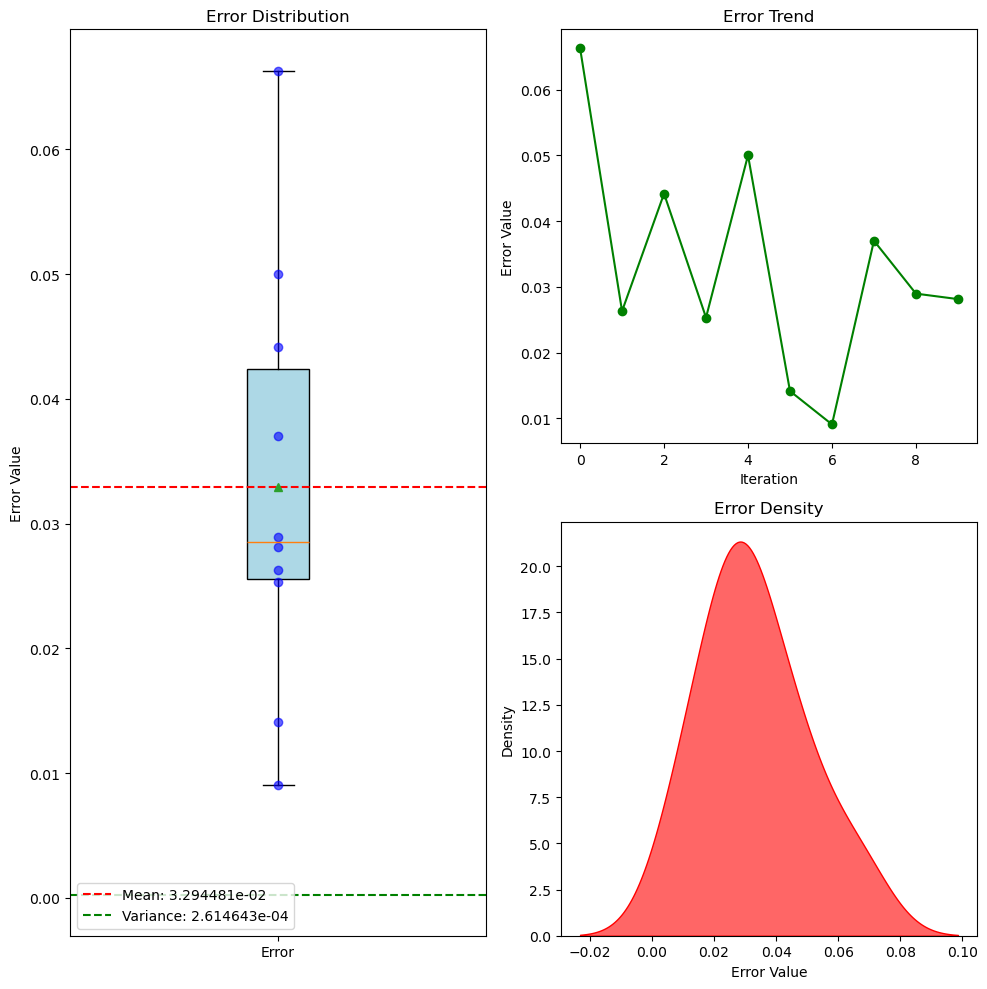

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  
error = error_u

plt.figure(figsize=(10, 10))  
plt.subplot(1, 2, 1) 
mean_error = np.mean(error)
var_error = np.var(error)
print('mean Error u: %e' % (mean_error)) 
print('Variance Error u: %e' % (var_error)) 


plt.subplot(1, 2, 1)
plt.boxplot(error, patch_artist=True, showmeans=True, meanline=False, boxprops=dict(facecolor='lightblue'))
plt.axhline(mean_error, color='r', linestyle='--', label=f'Mean: {mean_error:e}')
plt.axhline(var_error, color='g', linestyle='--', label=f'Variance: {var_error:e}')  
for i, value in enumerate(error):
    plt.plot(1, value, 'bo', alpha=0.6)
plt.title('Error Distribution')
plt.ylabel('Error Value')
plt.xticks([1], ['Error'])
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(error, '-o', color='green')
plt.title('Error Trend')
plt.ylabel('Error Value')
plt.xlabel('Iteration')

plt.subplot(2, 2, 4)
sns.kdeplot(error, shade=True, color="r", alpha=0.6)
plt.title('Error Density')
plt.xlabel('Error Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [10]:
len_t = 101
len_x = 101


flat_X = X_star[:, 0]
flat_T = X_star[:, 1]


X = flat_X.reshape(len_t, len_x)
T = flat_T.reshape(len_t, len_x)

U_star = griddata(X_star, u_star.flatten(), (X, T), method='cubic')


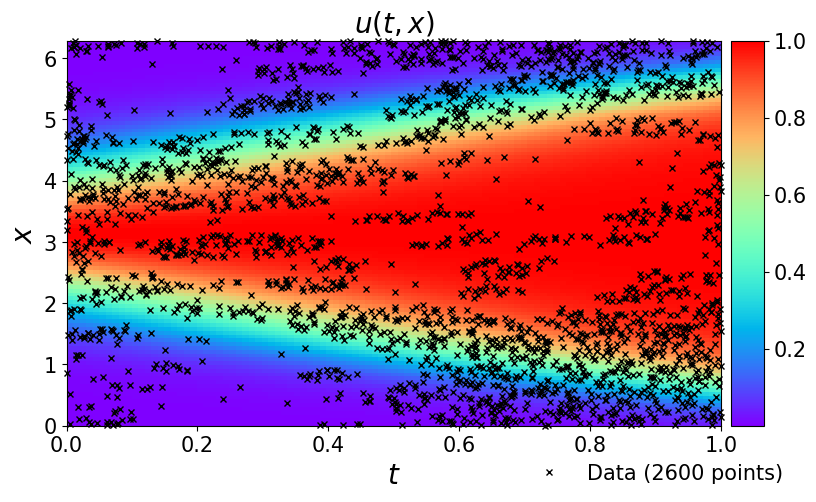

In [11]:
fig = plt.figure(figsize=(9, 5)) 
ax = fig.add_subplot(111) 
im = ax.imshow(U_star.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')  


divider = make_axes_locatable(ax) 
cax = divider.append_axes("right", size="5%", pad=0.10) 
   
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=15) 
ax.plot(
    X_f[:,1], 
    X_f[:,0], 
    'kx', label = 'Data (%d points)' % (X_f.shape[0]), 
    markersize = 4,  
    clip_on = False,
    alpha=1.0
) 

ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
ax.set_title('$u(t,x)$', fontsize = 20) 
ax.tick_params(labelsize=15)

plt.show() 

In [12]:
trainloss = torch.stack(model.loss_value).cpu().detach().numpy()


15443


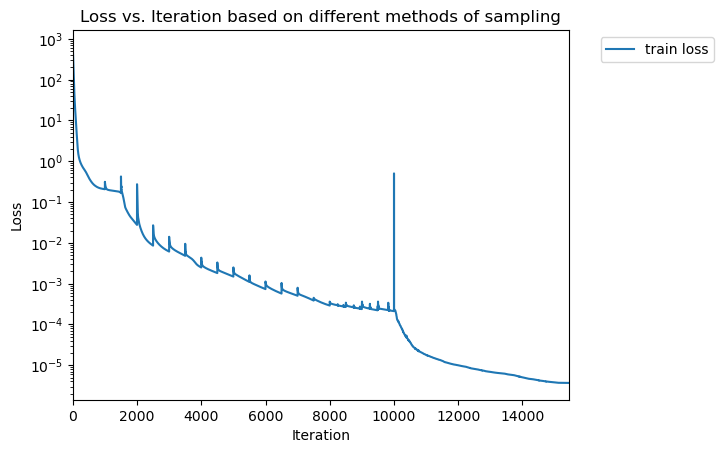

In [13]:
print(len(trainloss))

labels = ["Grid"]

plt.figure()


plt.plot(trainloss, label='train loss')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.xlim([0,len(trainloss)]) 
plt.yscale('log') 
plt.xlabel('Iteration') 
plt.ylabel('Loss') 
plt.title('Loss vs. Iteration based on different methods of sampling') 
plt.show()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


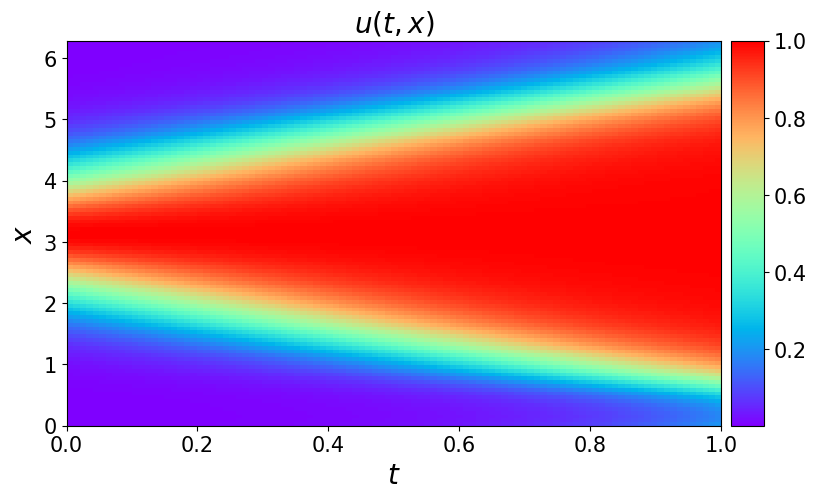

In [14]:
#使用griddata函数将X_star、u_pred插值到网格上，得到U_pred
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')


###### Row 0: u(t,x) ##################    

fig = plt.figure(figsize=(9, 5)) #这里figure是一个figure对象，是一个图形窗口，代表整个图形，设置图形大小为宽9英寸高5 英寸
ax = fig.add_subplot(111) #在图形的1*1网格的第一个位置添加一个子图

#绘图的数据来源
im = ax.imshow(U_pred.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')   #imshow函数用于显示图像，接受一些参数，第一个参数是图像数据，这里是U_pred的转置；第二个参数是插值方法（用于在像素之间插入新的像素），这里是最邻近插值；


#添加颜色条
divider = make_axes_locatable(ax)  #使用 make_axes_locatable 函数创建了一个 AxesDivider 对象。这个函数接受一个 Axes 对象作为参数，返回一个 AxesDivider 对象。AxesDivider 对象可以用来管理子图的布局，特别是当你需要在一个图的旁边添加另一个图时。
cax = divider.append_axes("right", size="5%", pad=0.10) #使用append_axes方法在原始轴的右侧添加了一个新的轴。append_axes 方法接受三个参数：位置（"right"）、大小（"5%"）和间距（0.10）。在原始轴的右侧添加了一个新的轴，新轴的大小是原始轴的 5%，新轴与原始轴之间的间距是 0.05 英寸
   
cbar = fig.colorbar(im, cax=cax)#使用colorbar方法在新轴上添加了一个颜色条。colorbar 方法接受两个参数：axesimage 对象（im）和新轴（cax）。并记这个颜色条的名字是cbar
cbar.ax.tick_params(labelsize=15) #设置颜色条刻度标签大小，这里bar是之前定义的


# #在图上绘制散点图
# ax.plot(
#     X_f_train[:,1], 
#     X_f_train[:,0], 
#     'kx', label = 'Data (%d points)' % (X_f_train.shape[0]), 
#     markersize = 4,  # marker size doubled
#     clip_on = False,
#     alpha=1.0
# ) #在ax上绘制散点图，前两个参数是散点的x坐标和y坐标；kx表示黑色的x（散点形状是x），label是散点的标签，clip_on表示散点可以绘制在轴的边界外
#   #新加了一个alpha=1.0用来设置标记的透明度，1.0表示完全不透明  




#设置图的标签、图例、标题和刻度标签
#设置ax子图的x轴的标签为t，y轴的标签为x。这里$t$和$x$是latex格式的文本，用于生成数学公式
ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
#设置子图ax的图例，第一个参数用来设置图例的位置，这里表示图例放在上方中央;第二个参数用来设置图例的锚点，接受一个元组，表示x和y坐标，表示把图例的锚点设置在x坐标为0.9，y坐标为-0.05处;frameon=False表示不显示图例的边框;第三个参数设置图例的列数，分为5列；最后一个参数设置图例属性，接受字典，这里表示设置图例字体大小为15；最后返回的leg是一个legend对象，表示图形的图例
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
#设置子图ax的标题为$u(t,x)$，表示latex格式的文本，用于生成数学公式，fontsize=10表示字体大小为20
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled，两倍化子图标题
ax.tick_params(labelsize=15)#用来设置刻度标签的大小。`tick_params`是`Axes`对象的一个方法，可以用来设置刻度线的属性。在这里，`labelsize=15` 是用来设置刻度标签的字体大小的。


#显示图片
plt.show() #显示所有打开的图形的函数

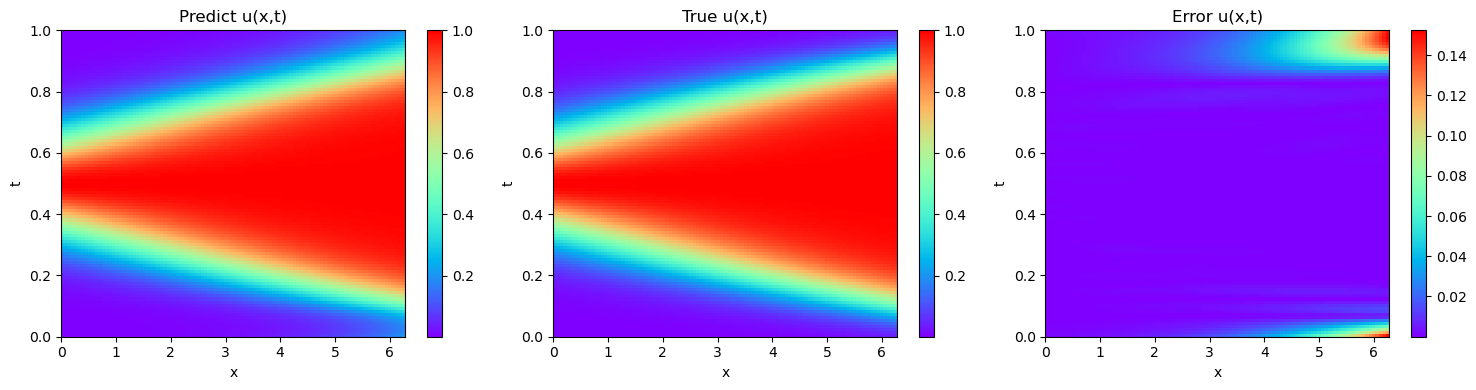

In [15]:

# 创建一个包含三幅子图的图像
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 绘制第一幅图像
axes[0].imshow(U_pred.T, extent=[0, np.pi*2, 1, 0], aspect='auto', cmap='rainbow')
axes[0].invert_yaxis()
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title('Predict u(x,t)')
fig.colorbar(axes[0].images[0], ax=axes[0])

# 绘制第二幅图像
axes[1].imshow(U_star.T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[1].invert_yaxis()
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
axes[1].set_title('True u(x,t)')
fig.colorbar(axes[1].images[0], ax=axes[1])

# 绘制第三幅图像
axes[2].imshow(np.abs(U_pred - U_star).T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[2].invert_yaxis()
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
axes[2].set_title('Error u(x,t)')
fig.colorbar(axes[2].images[0], ax=axes[2])

# 自动调整子图参数，使得子图之间的间距适当
plt.tight_layout()
plt.show()